---
### ℹ️ Sobre a Fonte dos Dados e Licenciamento

Este projeto utiliza o **Travel Dataset - Guide to India's Must-See Places**, compilado e disponibilizado por **saketk511** na plataforma Kaggle.

* **Origem dos Dados:** [Kaggle - Travel Dataset](https://www.kaggle.com/datasets/saketk511/travel-dataset-guide-to-indias-must-see-places)
* **Autor Original:** saketk511
* **Licença de Uso:** *[Insira a licença confirmada na página, ex: PDDL, CC0 ou ODC-By]*
* **Conteúdo:** A base de dados mapeia os principais destinos turísticos da Índia (`Top Indian Places to Visit.csv`). Ela inclui detalhes valiosos sobre cada local, como Zona, Estado, Cidade, Tipo de Atração (ex: Monumento, Túmulo, etc.), Ano de Estabelecimento, Avaliação no Google, Preço do Ingresso (em INR), Tempo Estimado de Visita e a Melhor Época para visitar.
* **Uso e Modificações:** Os dados brutos foram importados, limpos e estruturados utilizando a biblioteca Pandas em Python. Esta Análise Exploratória de Dados (EDA) foi conduzida para o canal **Insight em Dados** e os arquivos resultantes estão disponíveis para estudo no nosso repositório oficial.
---

#Bloco 1: Inicialização e Visão Geral

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuração visual padronizada para os gráficos
sns.set_theme(style="whitegrid", palette="muted")

# Carga dos dados
df = pd.read_csv('Top Indian Places to Visit.csv')

# Visão geral
print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")
display(df.info())
display(df.head(3))

Linhas: 325 | Colunas: 16
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 325 entries, 0 to 324
Data columns (total 16 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Unnamed: 0                        325 non-null    int64  
 1   Zone                              325 non-null    object 
 2   State                             325 non-null    object 
 3   City                              325 non-null    object 
 4   Name                              325 non-null    object 
 5   Type                              325 non-null    object 
 6   Establishment Year                325 non-null    object 
 7   time needed to visit in hrs       325 non-null    float64
 8   Google review rating              325 non-null    float64
 9   Entrance Fee in INR               325 non-null    int64  
 10  Airport with 50km Radius          325 non-null    object 
 11  Weekly Off                        32 non-null

None

,Unnamed: 0,Zone,State,City,Name,Type,Establishment Year,time needed to visit in hrs,Google review rating,Entrance Fee in INR,Airport with 50km Radius,Weekly Off,Significance,DSLR Allowed,Number of google review in lakhs,Best Time to visit
0,0,Northern,Delhi,Delhi,India Gate,War Memorial,1921,0.5,4.6,0,Yes,NaN,Historical,Yes,2.6,Evening
1,1,Northern,Delhi,Delhi,Humayun's Tomb,Tomb,1572,2.0,4.5,30,Yes,NaN,Historical,Yes,0.4,Afternoon
2,2,Northern,Delhi,Delhi,Akshardham Temple,Temple,2005,5.0,4.6,60,Yes,NaN,Religious,No,0.4,Afternoon


#Bloco 2: Limpeza e Engenharia de Atributos (Data Cleaning)

In [ ]:
# 1. Remoção de coluna residual
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# 2. Tratamento da coluna 'Weekly Off' (293 nulos identificados)
# Como ~90% são nulos, criamos uma variável booleana indicando se o local fecha algum dia
df['Has_Weekly_Off'] = df['Weekly Off'].notnull()

# 3. Padronização de strings em 'Best Time to visit'
# Corrigindo espaços extras e termos sinônimos ('All ', 'Anytime')
df['Best Time to visit'] = df['Best Time to visit'].str.strip().replace({'Anytime': 'All'})

# 4. Conversão do Ano de Estabelecimento
# Convertendo 'Unknown' para NaN e alterando o tipo para numérico
df['Establishment Year'] = pd.to_numeric(df['Establishment Year'].replace('Unknown', np.nan), errors='coerce')

print("Dados após a limpeza:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Dados após a limpeza:
Establishment Year    124
Weekly Off            293
dtype: int64


#Bloco 3: Distribuição Geográfica (Macro e Micro)

/tmp/ipykernel_903/2131792882.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Zone', order=df['Zone'].value_counts().index, ax=axes[0], palette='Blues_r')
/tmp/ipykernel_903/2131792882.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_states.index, x=top_states.values, ax=axes[1], palette='crest')


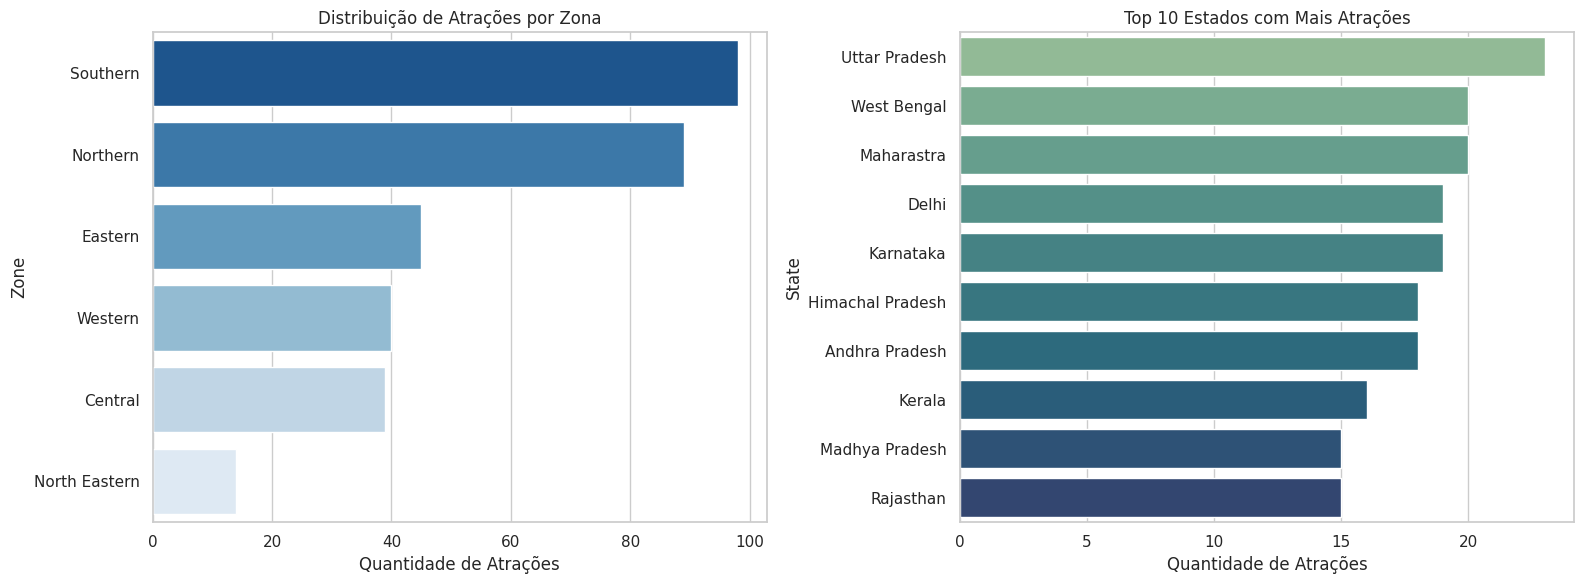

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Zonas
sns.countplot(data=df, y='Zone', order=df['Zone'].value_counts().index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Distribuição de Atrações por Zona')
axes[0].set_xlabel('Quantidade de Atrações')

# Gráfico 2: Top 10 Estados
top_states = df['State'].value_counts().head(10)
sns.barplot(y=top_states.index, x=top_states.values, ax=axes[1], palette='crest')
axes[1].set_title('Top 10 Estados com Mais Atrações')
axes[1].set_xlabel('Quantidade de Atrações')

plt.tight_layout()
plt.show()

#Bloco 4: A Vocação Turística (Significância e Tipo)

/tmp/ipykernel_903/3535120309.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_sig.values, y=top_sig.index, palette='flare')


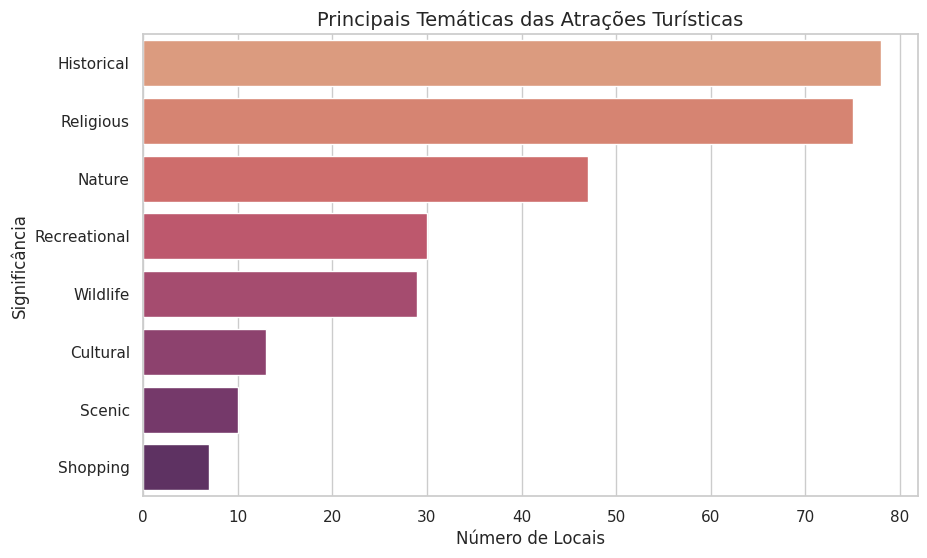

In [ ]:
plt.figure(figsize=(10, 6))
top_sig = df['Significance'].value_counts().head(8)
sns.barplot(x=top_sig.values, y=top_sig.index, palette='flare')

plt.title('Principais Temáticas das Atrações Turísticas', fontsize=14)
plt.xlabel('Número de Locais')
plt.ylabel('Significância')
plt.show()

#Bloco 5: Análise de Satisfação e Busca por Outliers

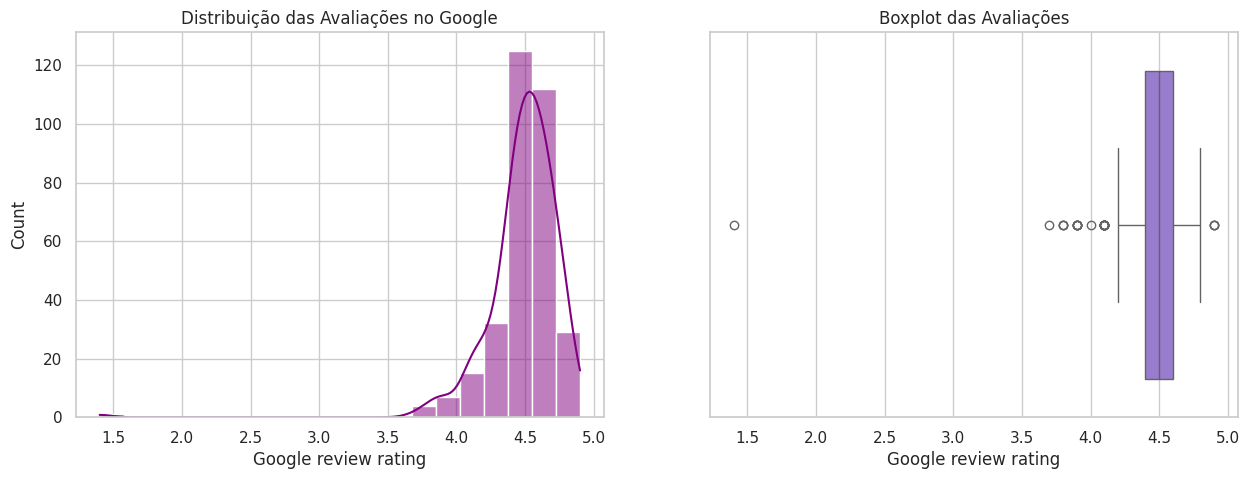

Outlier de baixa avaliação encontrado:


,Name,Type,Google review rating
26,Imagicaa,Amusement Park,1.4


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribuição das notas
sns.histplot(df['Google review rating'], bins=20, kde=True, color='purple', ax=axes[0])
axes[0].set_title('Distribuição das Avaliações no Google')

# Identificando Outliers com Boxplot
sns.boxplot(x=df['Google review rating'], color='mediumpurple', ax=axes[1])
axes[1].set_title('Boxplot das Avaliações')

plt.show()

# Isolando a anomalia severa
outlier = df[df['Google review rating'] < 3.0][['Name', 'Type', 'Google review rating']]
print("Outlier de baixa avaliação encontrado:")
display(outlier)

#Bloco 6: Dinâmica de Custos vs. Tempo (Análise Bivariada)

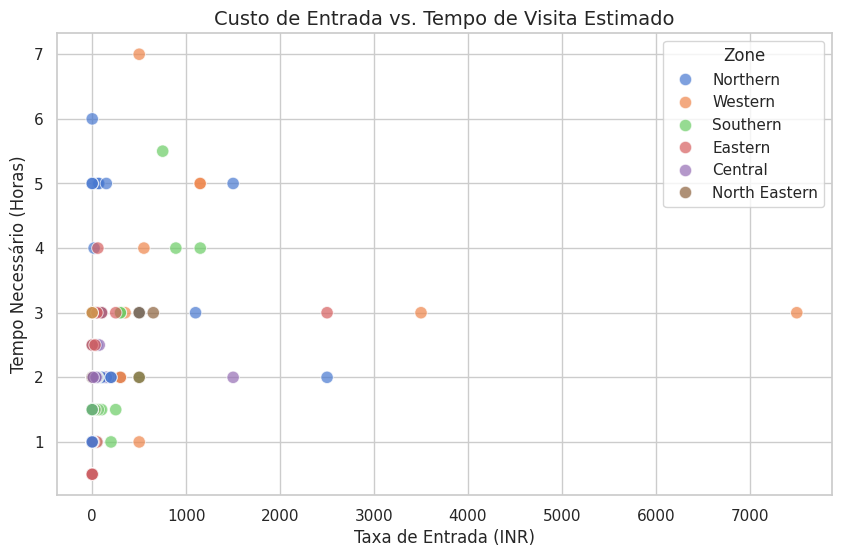

Correlação de Pearson: 0.28


In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Entrance Fee in INR', y='time needed to visit in hrs',
                hue='Zone', alpha=0.7, s=80)

plt.title('Custo de Entrada vs. Tempo de Visita Estimado', fontsize=14)
plt.xlabel('Taxa de Entrada (INR)')
plt.ylabel('Tempo Necessário (Horas)')
plt.show()

# Calculando a correlação
corr = df['Entrance Fee in INR'].corr(df['time needed to visit in hrs'])
print(f"Correlação de Pearson: {corr:.2f}")

#Bloco 7: Infraestrutura e Restrições de Equipamento

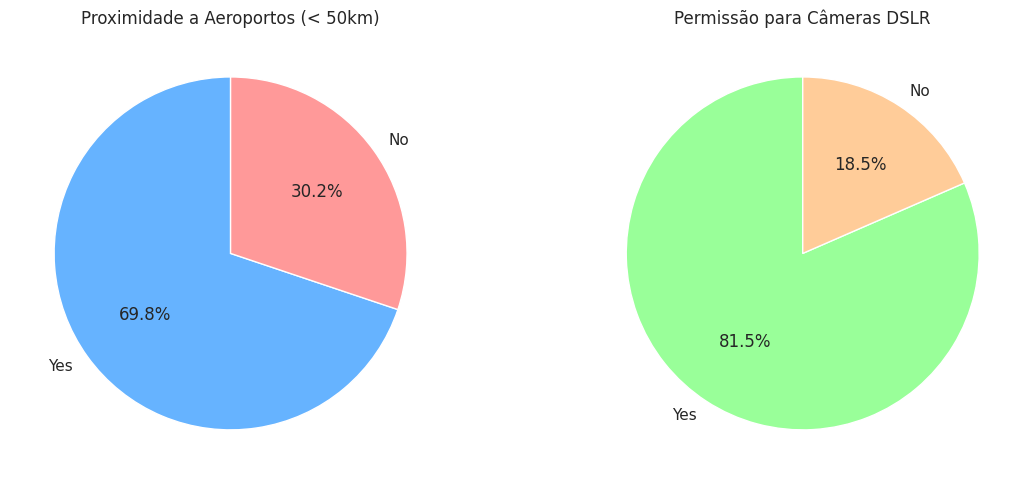

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Aeroportos
df['Airport with 50km Radius'].value_counts().plot.pie(
    autopct='%1.1f%%', ax=axes[0], colors=['#66b3ff','#ff9999'], startangle=90)
axes[0].set_title('Proximidade a Aeroportos (< 50km)')
axes[0].set_ylabel('')

# Câmeras DSLR
df['DSLR Allowed'].value_counts().plot.pie(
    autopct='%1.1f%%', ax=axes[1], colors=['#99ff99','#ffcc99'], startangle=90)
axes[1].set_title('Permissão para Câmeras DSLR')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

#Bloco 8: Engajamento vs. Momento Ideal

/tmp/ipykernel_903/1024440958.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=time_df, x='Best Time to visit', y='Number of google review in lakhs', palette='Set2')


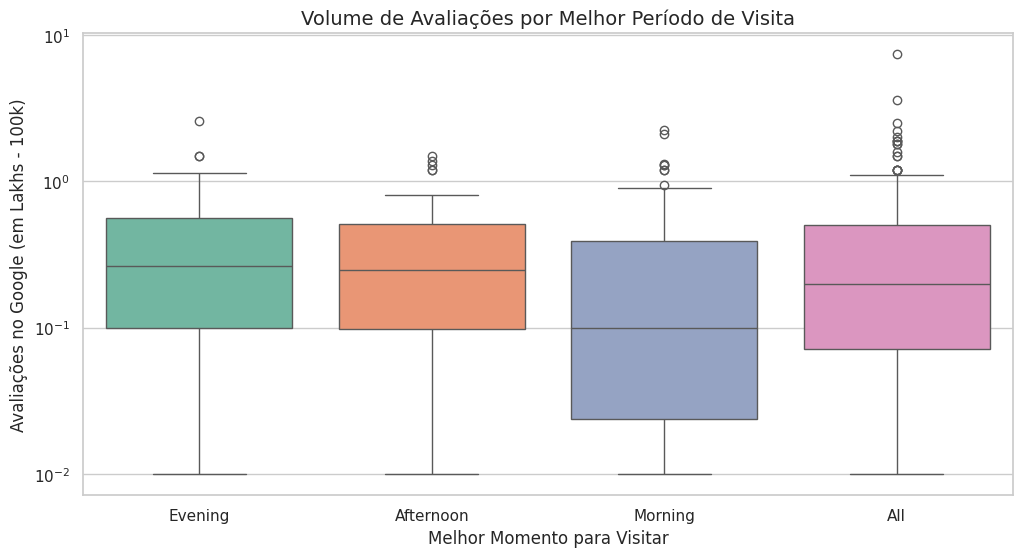

In [ ]:
plt.figure(figsize=(12, 6))
# Removemos os nulos e filtramos momentos específicos
time_df = df[df['Best Time to visit'].isin(['Morning', 'Afternoon', 'Evening', 'All'])]

sns.boxplot(data=time_df, x='Best Time to visit', y='Number of google review in lakhs', palette='Set2')
plt.title('Volume de Avaliações por Melhor Período de Visita', fontsize=14)
plt.xlabel('Melhor Momento para Visitar')
plt.ylabel('Avaliações no Google (em Lakhs - 100k)')
plt.yscale('log') # Escala logarítmica para lidar com o peso de locais super populares
plt.show()

#Bloco 9: Teste de Hipóteses (Inferência Estatística)

In [ ]:
from scipy import stats

# Removendo eventuais nulos nas colunas de interesse para o teste
test_data = df.dropna(subset=['Zone', 'Google review rating'])

# Agrupando as avaliações por Zona
zones = test_data['Zone'].unique()
zone_groups = [test_data[test_data['Zone'] == z]['Google review rating'] for z in zones]

# Executando o Teste de Kruskal-Wallis
kw_stat, kw_p = stats.kruskal(*zone_groups)

print(f"Estatística H: {kw_stat:.4f}")
print(f"Valor-p (P-value): {kw_p:.4f}")

# Interpretando o resultado
alpha = 0.05
if kw_p < alpha:
    print("Conclusão: Há uma diferença estatisticamente significativa nas notas entre as zonas.")
else:
    print("Conclusão: Falhamos em rejeitar a hipótese nula. Não há diferença estatisticamente significativa nas notas entre as zonas.")

Estatística H: 6.9543
Valor-p (P-value): 0.2241
Conclusão: Falhamos em rejeitar a hipótese nula. Não há diferença estatisticamente significativa nas notas entre as zonas.


#Bloco 10: Criando um Motor de Recomendação Simples

In [ ]:
def recomendar_locais(df, budget_max_inr, horas_disponiveis, top_n=5):
    """
    Retorna os melhores locais para visitar com base no orçamento e tempo do turista.
    """
    # Garantindo que os tipos estejam corretos para a filtragem
    df['Entrance Fee in INR'] = pd.to_numeric(df['Entrance Fee in INR'], errors='coerce').fillna(0)
    df['time needed to visit in hrs'] = pd.to_numeric(df['time needed to visit in hrs'], errors='coerce').fillna(0.5)

    # Aplicando as regras de negócio
    recomendacoes = df[
        (df['Entrance Fee in INR'] <= budget_max_inr) &
        (df['time needed to visit in hrs'] <= horas_disponiveis)
    ]

    # Ordenando por Nota do Google e Volume de Avaliações (desempate)
    recomendacoes = recomendacoes.sort_values(
        by=['Google review rating', 'Number of google review in lakhs'],
        ascending=[False, False]
    )

    colunas_finais = ['Name', 'City', 'Type', 'Google review rating', 'Entrance Fee in INR']
    return recomendacoes.head(top_n)[colunas_finais]

# Simulando um mochileiro com pouco dinheiro (Até 100 INR) e pouco tempo (Até 3 horas)
display(recomendar_locais(df, budget_max_inr=100, horas_disponiveis=3, top_n=3))

,Name,City,Type,Google review rating,Entrance Fee in INR
92,Golden Temple (Harmandir Sahib),Amritsar,Religious Site,4.9,0
196,Pangong Tso,Leh,Lake,4.9,20
306,Kedarnath,Kedarnath,Temple,4.8,0
